In [2]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

DATA_PATH  = library_path.parent / 'data'
PLOTS_PATH = library_path.parent / 'plots'
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## Norm Derivation — Restricted Pipeline

### What this notebook does

This notebook derives population reference norms for seven EQ-5D-5L outcomes by applying
importance-weighted estimation to DAPHNIE 2024, using HSE 2017–2018 as the target population.

### Statistical rationale

The core idea is **importance weighting** (covariate shift correction). The density ratio
$w(x) = P_{\text{target}}(x) / P_{\text{source}}(x)$ transforms an expectation under the
source distribution into one under the target distribution:

$$\mathbb{E}_{\text{target}}[Y] \approx \frac{\sum_i w(x_i)\, y_i}{\sum_i w(x_i)}$$

where the sum is over DAPHNIE 2024 observations. When $w$ is well-estimated, this recovers
the population mean we would observe if DAPHNIE had been drawn from the same frame as HSE.

### Design

- **Density ratio:** re-estimated here from scratch using plain logistic regression on the
  15-variable predictor set — same architecture as notebook 031. Plain LR is the recommended
  scheme (best post-reweighting balance with 3 residual imbalanced variables, ESS ≈ 74.5%).
- **Reference:** HSE 2017–2018 survey-weighted with `wt_int`.
- **DAPHNIE unadjusted:** DAPHNIE 2024 design-weighted with `svy_wt`.
- **DAPHNIE adjusted:** weighted with `svy_wt × w_LR`.
- **Missingness:** complete-case analysis per outcome. ~10% block missing on EQ-5D in HSE
  2017–18 (not MCAR; systematically less healthy — stated limitation for abstract).

In [4]:
df = pd.read_csv(DATA_PATH / 'wrangled_data.csv', low_memory=False)

hse_1718   = df[df['dataset'].isin(['HSE 2017', 'HSE 2018'])].copy().reset_index(drop=True)
daphnie_24 = df[df['dataset'] == 'DAPHNIE 2024'].copy().reset_index(drop=True)

print(f'HSE 2017–2018: n = {len(hse_1718):,}')
print(f'DAPHNIE 2024:  n = {len(daphnie_24):,}')

HSE 2017–2018: n = 16,173
DAPHNIE 2024:  n = 5,237


In [5]:
# 17-variable predictor set (notebook 031)
FEATURES = [
    'Sex', 'age7cat',
    'eth2cat',
    'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired',
    'emp_cat_Student', 'emp_cat_Unemployed',
    'edu_cat_2',
    'paVig', 'paMod',
    'smoke_ecig', 'diabetes',
    'meds_num', 'ill_dis',
    'resp', 'skin',
]
FEATURES = [f for f in FEATURES if f in df.columns]
assert len(FEATURES) == 17, f'Expected 17 features, got {len(FEATURES)}'
print(f'Feature set ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  {f}')

Feature set (17):
  Sex
  age7cat
  eth2cat
  emp_cat_Employed
  emp_cat_Other (Sick/Home/etc)
  emp_cat_Retired
  emp_cat_Student
  emp_cat_Unemployed
  edu_cat_2
  paVig
  paMod
  smoke_ecig
  diabetes
  meds_num
  ill_dis
  resp
  skin


## Step 1: Density Ratio Re-estimation

Plain logistic regression with `class_weight='balanced'` is trained to distinguish
DAPHNIE 2024 (label = 0) from HSE 2017–2018 (label = 1) using the 15 predictors.
Equalising the class prior means the predicted probability odds are directly the
density ratio:

$$w(x) = \frac{\hat{p}(x)}{1 - \hat{p}(x)}$$

No sample-size correction is needed because `class_weight='balanced'` already
absorbs the marginal class imbalance (DAPHNIE:HSE ≈ 1:3.1).

Weights are clipped at the 99th percentile to prevent extreme observations from
dominating the weighted estimator, then renormalised to mean 1.

In [6]:
def fit_lr_density_ratio(source_df, target_df, features):
    """
    Pool source (label=0) and target (label=1); fit a balanced logistic regression.
    Returns the fitted sklearn Pipeline.
    """
    src    = source_df[features].assign(_label=0)
    tgt    = target_df[features].assign(_label=1)
    pooled = pd.concat([src, tgt], ignore_index=True)
    X, y   = pooled[features], pooled['_label']

    lr = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ])
    lr.fit(X, y)
    return lr


def compute_weights(clf, source_X, clip_percentile=99):
    """
    Density ratio weights w(x) = p/(1-p), normalised to mean 1,
    clipped at clip_percentile.
    Returns (weights_array, clip_value, n_clipped, effective_sample_size).
    """
    p_hat = clf.predict_proba(source_X)[:, 1]
    w     = p_hat / (1 - p_hat + 1e-8)
    w     = w / w.mean()

    clip_val  = np.percentile(w, clip_percentile)
    n_clipped = int((w > clip_val).sum())
    w         = np.clip(w, 0, clip_val)
    w         = w / w.mean()

    n_eff = w.sum() ** 2 / (w ** 2).sum()
    return w, clip_val, n_clipped, n_eff

In [7]:
lr_model = fit_lr_density_ratio(daphnie_24, hse_1718, FEATURES)
w_lr, clip_val, n_clipped, n_eff = compute_weights(lr_model, daphnie_24[FEATURES])

print('LR density ratio weights (99th-pct clip):')
print(f'  Clip value:          {clip_val:.3f}')
print(f'  Clipped observations: {n_clipped} ({100*n_clipped/len(daphnie_24):.1f}%)')
print(f'  ESS:                 {n_eff:.0f} / {len(daphnie_24)} ({100*n_eff/len(daphnie_24):.1f}%)')
print(f'  Weight range:        [{w_lr.min():.3f}, {w_lr.max():.3f}]  mean = {w_lr.mean():.3f}')

LR density ratio weights (99th-pct clip):
  Clip value:          4.872
  Clipped observations: 52 (1.0%)
  ESS:                 3022 / 5237 (57.7%)
  Weight range:        [0.026, 4.948]  mean = 1.000


## Step 2: Outcome Variables

Eight outcomes are in scope for the abstract analysis:

| Variable | Type | Description |
|---|---|---|
| `MO5L` | ordinal 1–5 | Mobility |
| `SC5L` | ordinal 1–5 | Self-care |
| `UA5L` | ordinal 1–5 | Usual activities |
| `PD5L` | ordinal 1–5 | Pain/discomfort |
| `AD5L` | ordinal 1–5 | Anxiety/depression |
| `EQ_index` | continuous | EQ-5D-5L utility index (UK value set) |
| `LSS_rs` | continuous, 0–100 | Leidelmeijer Severity Score |
| `srh` | ordinal 1–5 | Self-rated health |

All analyses are complete-case per outcome.

In [9]:
DIMENSIONS  = ['MO5L', 'SC5L', 'UA5L', 'PD5L', 'AD5L']
CONTINUOUS  = ['EQ_index', 'LSS_rs']
ALL_OUTCOMES = DIMENSIONS + CONTINUOUS + ['srh']

print(f'  {"Outcome":<14}  {"DAPHNIE 2024":>13}  {"HSE 2017–18":>12}')
print(f'  {"-"*42}')
for out in ALL_OUTCOMES:
    m_d = 100 * daphnie_24[out].isna().mean()
    m_h = 100 * hse_1718[out].isna().mean()
    print(f'  {out:<14}  {m_d:>12.1f}%  {m_h:>11.1f}%')

  Outcome          DAPHNIE 2024   HSE 2017–18
  ------------------------------------------
  MO5L                     0.3%          9.9%
  SC5L                     0.5%          9.9%
  UA5L                     0.8%          9.8%
  PD5L                     0.6%          9.8%
  AD5L                     0.6%         10.0%
  EQ_index                 1.8%         10.9%
  LSS_rs                   1.8%         10.9%
  srh                      6.1%          0.0%


## Step 3: Population Norm Estimation

For each outcome, we estimate the population mean under three conditions:

| Condition | Sample | Weights |
|---|---|---|
| **HSE 2017–18** | HSE 2017–2018 | `wt_int` (official survey weights) |
| **DAPHNIE (unadjusted)** | DAPHNIE 2024 | `svy_wt` (quota-sample design weights) |
| **DAPHNIE (adjusted)** | DAPHNIE 2024 | `svy_wt × w_LR` |

The estimator is the Horvitz–Thompson weighted mean. Standard errors use the sandwich
estimator, which is valid regardless of the weight distribution:

$$\widehat{\mathrm{SE}} = \sqrt{\frac{\sum_i w_i^2 (y_i - \bar{y}_w)^2}{\left(\sum_i w_i\right)^2}}$$

For binary outcomes (FULLHEALTH, % any problem per dimension), this reduces to the
weighted binomial proportion SE. Confidence intervals: $\bar{y}_w \pm 1.96\,\widehat{\mathrm{SE}}$.

In [10]:
def wmean_se(y, w):
    """
    Weighted mean and sandwich SE.
    y, w: array-like (NaN in y is excluded; only finite positive w are used).
    Returns (mean, se).
    """
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(y) & np.isfinite(w) & (w > 0)
    if mask.sum() == 0:
        return np.nan, np.nan
    y_, w_ = y[mask], w[mask]
    W   = w_.sum()
    mu  = np.dot(w_, y_) / W
    var = np.sum(w_**2 * (y_ - mu)**2) / W**2
    return mu, np.sqrt(var)


# Positional weight arrays (aligned with each reset-indexed dataframe)
HSE_W   = hse_1718['wt_int'].fillna(1.0).values
D24_SWY = daphnie_24['svy_wt'].fillna(1.0).values
D24_ADJ = D24_SWY * w_lr

# (label, dataframe, weight_array) triples used throughout
CONDITIONS = [
    ('HSE 2017–18',          hse_1718,   HSE_W),
    ('DAPHNIE (unadjusted)', daphnie_24, D24_SWY),
    ('DAPHNIE (adjusted)',   daphnie_24, D24_ADJ),
]

COND_COLORS = {
    'HSE 2017–18':          '#2ca02c',
    'DAPHNIE (unadjusted)': '#d62728',
    'DAPHNIE (adjusted)':   '#1f77b4',
}

In [11]:
# Overall norms table: mean (95% CI) for each outcome under each condition
rows = []
for out in ALL_OUTCOMES:
    for cond_label, ds, wts in CONDITIONS:
        mu, se = wmean_se(ds[out].values, wts)
        n_obs  = int(np.isfinite(ds[out].values).sum())
        rows.append({
            'Outcome':   out,
            'Condition': cond_label,
            'n':         n_obs,
            'Mean':      mu,
            'SE':        se,
            'CI_lo':     mu - 1.96 * se,
            'CI_hi':     mu + 1.96 * se,
        })

norms_long = pd.DataFrame(rows)

# Wide format for display
norms_wide = (
    norms_long
    .pivot(index='Outcome', columns='Condition', values=['n', 'Mean', 'SE'])
    .reindex(ALL_OUTCOMES)
)
print('Population norms — weighted means and SEs:')
display(norms_wide.round(4))

Population norms — weighted means and SEs:


n                                   \
Condition DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18   
Outcome                                                         
MO5L               5223.0000            5223.0000  14574.0000   
SC5L               5210.0000            5210.0000  14571.0000   
UA5L               5195.0000            5195.0000  14592.0000   
PD5L               5206.0000            5206.0000  14582.0000   
AD5L               5204.0000            5204.0000  14560.0000   
EQ_index           5145.0000            5145.0000  14413.0000   
LSS_rs             5145.0000            5145.0000  14413.0000   
srh                4915.0000            4915.0000  16171.0000   

                        Mean                                   \
Condition DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18   
Outcome                                                         
MO5L                  1.4984               1.4264      1.3690   
SC5L                  1.2548               1.2274      1.1301   
UA5L                  1.5417               1.4656      1.3369   
PD5L                  1.8901               1.7952      1.6771   
AD5L                  2.0095               1.9141      1.4839   
EQ_index              0.8086               0.8311      0.8885   
LSS_rs               84.0221              85.8707     90.0981   
srh                   3.0116               3.1554      3.9876   

                          SE                                   
Condition DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18  
Outcome                                                        
MO5L                  0.0152               0.0113      0.0069  
SC5L                  0.0113               0.0087      0.0043  
UA5L                  0.0156               0.0118      0.0066  
PD5L                  0.0182               0.0134      0.0080  
AD5L                  0.0221               0.0157      0.0075  
EQ_index              0.0046               0.0035      0.0018  
LSS_rs                0.3130               0.2416      0.1325  
srh                   0.0201               0.0153      0.0080

In [12]:
# % reporting any problem (dimension level >= 2) for the five EQ-5D dimensions
anyproblem_rows = []
for dim in DIMENSIONS:
    for cond_label, ds, wts in CONDITIONS:
        y_bin          = ds[dim].copy().values.astype(float)
        y_bin          = np.where(np.isnan(y_bin), np.nan, (y_bin >= 2).astype(float))
        mu, se         = wmean_se(y_bin, wts)
        anyproblem_rows.append({
            'Dimension': dim,
            'Condition': cond_label,
            'pct_any':   100 * mu,
            'pct_se':    100 * se,
        })

ap_df = pd.DataFrame(anyproblem_rows)
ap_wide = ap_df.pivot(index='Dimension', columns='Condition', values=['pct_any', 'pct_se'])
print('% reporting any problem (level ≥ 2):')
display(ap_wide.reindex(DIMENSIONS).round(2))

% reporting any problem (level ≥ 2):


pct_any                                   \
Condition DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18   
Dimension                                                       
MO5L                 31.5600              26.6900     21.5200   
SC5L                 16.7500              14.4300      7.5400   
UA5L                 34.5100              29.1400     19.9300   
PD5L                 56.6500              51.8200     44.3300   
AD5L                 53.7200              50.6100     31.7100   

                      pct_se                                   
Condition DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18  
Dimension                                                      
MO5L                  0.8700               0.6100      0.3600  
SC5L                  0.6900               0.4900      0.2200  
UA5L                  0.8900               0.6300      0.3500  
PD5L                  0.9000               0.6900      0.4500  
AD5L                  0.9100               0.6900      0.4200

In [13]:
# Weighted % at each level (1–5) for each EQ-5D dimension
level_rows = []
for dim in DIMENSIONS:
    for cond_label, ds, wts in CONDITIONS:
        for lvl in range(1, 6):
            y_bin      = np.where(np.isnan(ds[dim].values), np.nan,
                                  (ds[dim].values == lvl).astype(float))
            mu, se     = wmean_se(y_bin, wts)
            level_rows.append({
                'Dimension': dim, 'Level': lvl,
                'Condition': cond_label,
                'pct':       100 * mu,
            })

level_df = pd.DataFrame(level_rows)
level_wide = (
    level_df
    .pivot(index=['Dimension', 'Level'], columns='Condition', values='pct')
    .reindex(pd.MultiIndex.from_product([DIMENSIONS, range(1, 6)],
                                        names=['Dimension', 'Level']))
)
print('Weighted % at each level (1–5):')
display(level_wide.round(1))

Weighted % at each level (1–5):


Condition        DAPHNIE (adjusted)  DAPHNIE (unadjusted)  HSE 2017–18
Dimension Level                                                       
MO5L      1                 68.4000               73.3000      78.5000
          2                 18.5000               15.4000      11.3000
          3                  8.5000                7.2000       5.6000
          4                  4.1000                3.5000       4.1000
          5                  0.6000                0.6000       0.5000
SC5L      1                 83.2000               85.6000      92.5000
          2                 10.1000                8.3000       3.7000
          3                  4.8000                4.3000       2.5000
          4                  1.5000                1.4000       1.0000
          5                  0.3000                0.4000       0.3000
UA5L      1                 65.5000               70.9000      80.1000
          2                 20.5000               17.0000      10.7000
          3                  9.2000                7.7000       5.6000
          4                  4.1000                3.7000       2.8000
          5                  0.8000                0.8000       0.8000
PD5L      1                 43.3000               48.2000      55.7000
          2                 34.3000               32.8000      27.5000
          3                 14.7000               12.4000      11.6000
          4                  5.3000                4.6000       4.1000
          5                  2.3000                2.0000       1.2000
AD5L      1                 46.3000               49.4000      68.3000
          2                 24.6000               25.1000      19.7000
          3                 16.5000               14.6000       8.4000
          4                  7.3000                6.6000       2.5000
          5                  5.4000                4.4000       1.1000

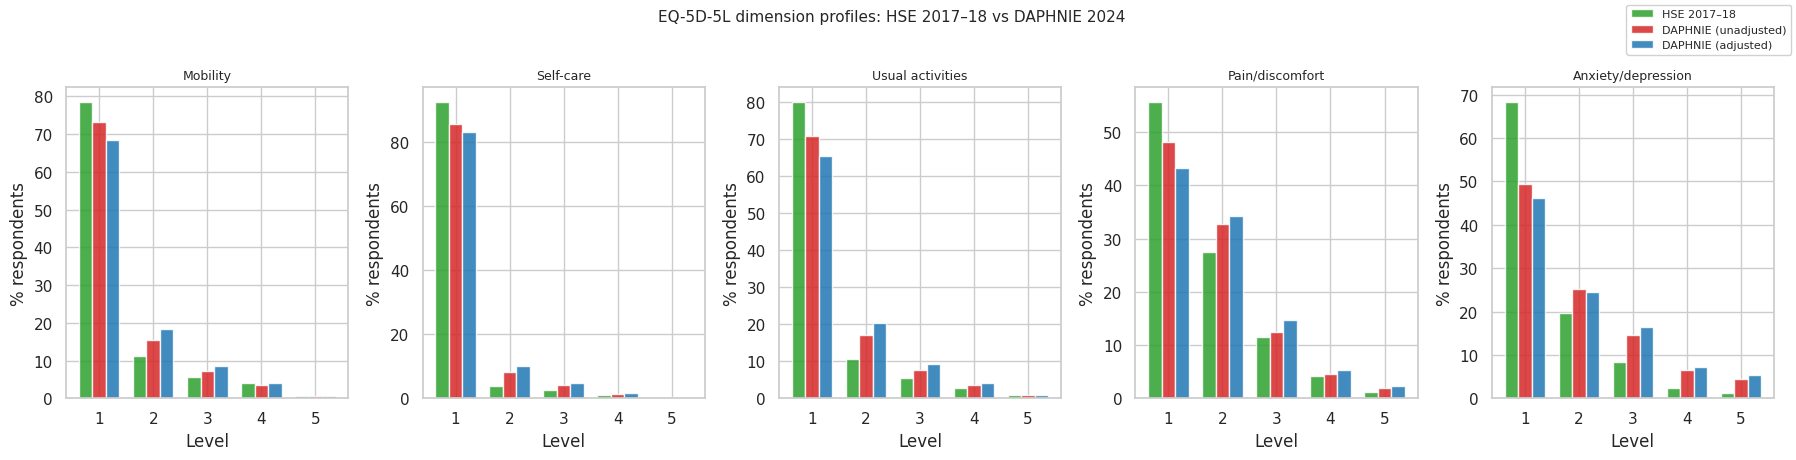

In [14]:
# Dimension profile plot: grouped bar per level for each dimension
DIM_LABELS = {
    'MO5L': 'Mobility',
    'SC5L': 'Self-care',
    'UA5L': 'Usual activities',
    'PD5L': 'Pain/discomfort',
    'AD5L': 'Anxiety/depression',
}

x       = np.arange(1, 6)
width   = 0.25
offsets = [-width, 0, width]

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5), sharey=False)
for ax, dim in zip(axes, DIMENSIONS):
    for offset, (cond_label, ds, wts) in zip(offsets, CONDITIONS):
        pcts = [
            100 * wmean_se(
                np.where(np.isnan(ds[dim].values), np.nan, (ds[dim].values == lvl).astype(float)),
                wts
            )[0]
            for lvl in range(1, 6)
        ]
        ax.bar(x + offset, pcts, width=width, label=cond_label,
               color=COND_COLORS[cond_label], alpha=0.85)

    ax.set_title(DIM_LABELS[dim], fontsize=9)
    ax.set_xlabel('Level')
    ax.set_xticks(x)
    ax.set_ylabel('% respondents')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=8, framealpha=0.9)
fig.suptitle('EQ-5D-5L dimension profiles: HSE 2017–18 vs DAPHNIE 2024',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'eq5d_dimension_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

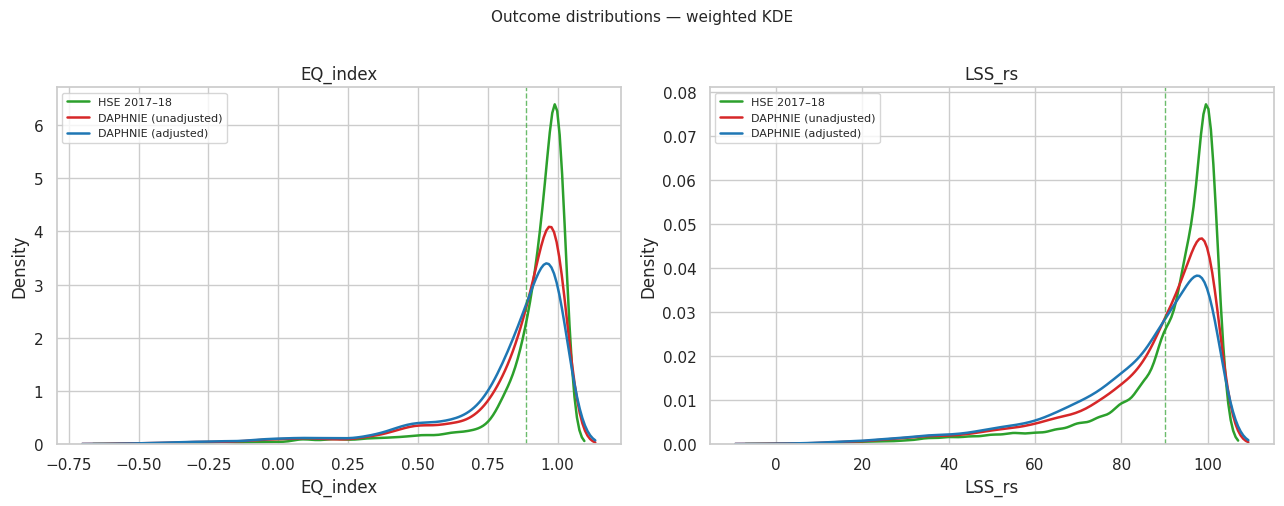

In [15]:
# Weighted KDE for EQ_index and LSS_rs
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, out in zip(axes, CONTINUOUS):
    for cond_label, ds, wts in CONDITIONS:
        y    = ds[out].values
        w    = wts.copy()
        mask = np.isfinite(y) & np.isfinite(w) & (w > 0)
        y_,  w_ = y[mask], w[mask]
        w_       = w_ / w_.sum()         # normalise to 1 for KDE
        sns.kdeplot(
            x=y_, weights=w_, ax=ax,
            label=cond_label,
            color=COND_COLORS[cond_label],
            linewidth=1.8,
        )
    mu_h = wmean_se(hse_1718[out].values, HSE_W)[0]
    ax.axvline(mu_h, color=COND_COLORS['HSE 2017–18'],
               linewidth=1.0, linestyle='--', alpha=0.7)
    ax.set_title(out)
    ax.set_xlabel(out)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Outcome distributions — weighted KDE', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'continuous_outcome_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Subgroup Norms by Sex × Age Group

EuroQoL population norms are conventionally reported stratified by sex and age group.
We use the `age7cat` variable (seven 10-year bands) and `Sex` (binary).

Weights for each subgroup are the same as overall — we restrict to the subgroup
and apply the pre-computed `svy_wt × w_LR` without renormalising within the
subgroup, preserving cross-subgroup comparability.

In [16]:
# Inspect coding before applying labels
print('age7cat distribution (DAPHNIE 2024):')
print(daphnie_24['age7cat'].value_counts().sort_index().to_string())
print()
print('age7cat distribution (HSE 2017–18):')
print(hse_1718['age7cat'].value_counts().sort_index().to_string())
print()
print('Sex distribution (DAPHNIE 2024):')
print(daphnie_24['Sex'].value_counts().sort_index().to_string())
print()
print('Sex distribution (HSE 2017–18):')
print(hse_1718['Sex'].value_counts().sort_index().to_string())

age7cat distribution (DAPHNIE 2024):
age7cat
1.0000    412
2.0000    915
3.0000    967
4.0000    968
5.0000    800
6.0000    811
7.0000    312

age7cat distribution (HSE 2017–18):
age7cat
1.0000    1394
2.0000    2222
3.0000    2625
4.0000    2740
5.0000    2708
6.0000    2564
7.0000    1920

Sex distribution (DAPHNIE 2024):
Sex
0.0000    2417
1.0000    2775

Sex distribution (HSE 2017–18):
Sex
0.0000    7203
1.0000    8970


In [17]:
# Adjust these mappings if the coding printout above differs from the labels here
AGE_LABELS = {1: '18–24', 2: '25–34', 3: '35–44', 4: '45–54',
              5: '55–64', 6: '65–74', 7: '75+'}
SEX_LABELS = {0: 'Male', 1: 'Female'}


def subgroup_norms(outcome, conditions, age_labels, sex_labels):
    """
    Compute weighted mean (and SE) for `outcome` within each Sex x age7cat cell.
    Returns a long-format DataFrame.
    """
    all_ages = sorted({int(v) for ds, _ in [(c[1], c[2]) for c in conditions]
                       for v in ds['age7cat'].dropna().unique()})
    all_sex  = sorted({int(v) for ds, _ in [(c[1], c[2]) for c in conditions]
                       for v in ds['Sex'].dropna().unique()})

    rows = []
    for sex_val in all_sex:
        for age_val in all_ages:
            for cond_label, ds, wts_arr in conditions:
                mask   = ((ds['Sex'] == sex_val) & (ds['age7cat'] == age_val)).values
                y_sub  = ds[outcome].values[mask]
                w_sub  = wts_arr[mask]
                mu, se = wmean_se(y_sub, w_sub)
                rows.append({
                    'Sex':       sex_labels.get(sex_val,  str(sex_val)),
                    'Age group': age_labels.get(age_val,  str(age_val)),
                    'Condition': cond_label,
                    'n':         int(mask.sum()),
                    'mean':      mu,
                    'SE':        se,
                })
    return pd.DataFrame(rows)


# EQ_index subgroup norms
sg_eq = subgroup_norms('EQ_index', CONDITIONS, AGE_LABELS, SEX_LABELS)
sg_eq_wide = (
    sg_eq
    .pivot(index=['Sex', 'Age group'], columns='Condition', values=['n', 'mean', 'SE'])
)
print('EQ-5D-5L utility index — weighted norms by sex and age group:')
display(sg_eq_wide.round(4))

EQ-5D-5L utility index — weighted norms by sex and age group:


n                                   \
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18   
Sex    Age group                                                       
Female 18–24               207.0000             207.0000    737.0000   
       25–34               486.0000             486.0000   1299.0000   
       35–44               574.0000             574.0000   1517.0000   
       45–54               530.0000             530.0000   1558.0000   
       55–64               431.0000             431.0000   1457.0000   
       65–74               384.0000             384.0000   1363.0000   
       75+                 136.0000             136.0000   1039.0000   
Male   18–24               202.0000             202.0000    657.0000   
       25–34               424.0000             424.0000    923.0000   
       35–44               391.0000             391.0000   1108.0000   
       45–54               432.0000             432.0000   1182.0000   
       55–64               360.0000             360.0000   1251.0000   
       65–74               413.0000             413.0000   1201.0000   
       75+                 173.0000             173.0000    881.0000   

                               mean                                   \
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18   
Sex    Age group                                                       
Female 18–24                 0.7928               0.8376      0.9167   
       25–34                 0.7807               0.8264      0.9187   
       35–44                 0.7678               0.7972      0.9061   
       45–54                 0.7626               0.7762      0.8664   
       55–64                 0.7855               0.8047      0.8545   
       65–74                 0.8407               0.8471      0.8527   
       75+                   0.8489               0.8600      0.7935   
Male   18–24                 0.8542               0.8602      0.9475   
       25–34                 0.8460               0.8751      0.9456   
       35–44                 0.8100               0.8485      0.9162   
       45–54                 0.7790               0.7983      0.8877   
       55–64                 0.8224               0.8416      0.8714   
       65–74                 0.8596               0.8822      0.8658   
       75+                   0.8485               0.8712      0.8381   

                                 SE                                   
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18  
Sex    Age group                                                      
Female 18–24                 0.0273               0.0146      0.0058  
       25–34                 0.0155               0.0105      0.0047  
       35–44                 0.0156               0.0123      0.0052  
       45–54                 0.0160               0.0132      0.0070  
       55–64                 0.0188               0.0133      0.0071  
       65–74                 0.0128               0.0116      0.0066  
       75+                   0.0259               0.0155      0.0084  
Male   18–24                 0.0195               0.0160      0.0044  
       25–34                 0.0130               0.0095      0.0044  
       35–44                 0.0183               0.0117      0.0077  
       45–54                 0.0176               0.0143      0.0075  
       55–64                 0.0155               0.0130      0.0071  
       65–74                 0.0131               0.0093      0.0070  
       75+                   0.0180               0.0132      0.0085

In [18]:
# Subgroup norms for all abstract outcomes
sg_all = {}
for out in ALL_OUTCOMES:
    sg_all[out] = subgroup_norms(out, CONDITIONS, AGE_LABELS, SEX_LABELS)

# Combined table: mean only, one outcome per column-group, sex x age as index
means_by_cond = {}
for out in ALL_OUTCOMES:
    tmp = sg_all[out].pivot(index=['Sex', 'Age group'], columns='Condition', values='mean')
    tmp.columns = pd.MultiIndex.from_product([[out], tmp.columns])
    means_by_cond[out] = tmp

sg_combined = pd.concat(means_by_cond.values(), axis=1)
print('Subgroup norms — weighted means by Sex × Age group (all abstract outcomes):')
display(sg_combined.round(4))

Subgroup norms — weighted means by Sex × Age group (all abstract outcomes):


MO5L                                   \
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18   
Sex    Age group                                                       
Female 18–24                 1.3331               1.2754      1.1350   
       25–34                 1.3949               1.2701      1.1482   
       35–44                 1.3645               1.3386      1.2164   
       45–54                 1.5579               1.5293      1.3853   
       55–64                 1.5956               1.5661      1.4820   
       65–74                 1.6791               1.6194      1.5876   
       75+                   1.7419               1.6691      2.0678   
Male   18–24                 1.2000               1.2239      1.1227   
       25–34                 1.2996               1.2518      1.0942   
       35–44                 1.3561               1.2923      1.2009   
       45–54                 1.4857               1.4535      1.3271   
       55–64                 1.4994               1.4556      1.4508   
       65–74                 1.6220               1.5024      1.6031   
       75+                   1.8811               1.7457      1.8671   

                               SC5L                                   \
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18   
Sex    Age group                                                       
Female 18–24                 1.3021               1.2670      1.0437   
       25–34                 1.2952               1.2000      1.0521   
       35–44                 1.2721               1.2654      1.0785   
       45–54                 1.3321               1.3214      1.1636   
       55–64                 1.2584               1.2413      1.1980   
       65–74                 1.2006               1.2063      1.1858   
       75+                   1.1279               1.1185      1.2852   
Male   18–24                 1.2201               1.2836      1.0289   
       25–34                 1.2048               1.1452      1.0385   
       35–44                 1.2514               1.1969      1.0872   
       45–54                 1.2933               1.2791      1.1360   
       55–64                 1.2328               1.2201      1.1809   
       65–74                 1.2583               1.1823      1.1907   
       75+                   1.2431               1.2164      1.2740   

                               UA5L                                   \
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2017–18   
Sex    Age group                                                       
Female 18–24                 1.5993               1.4634      1.1758   
       25–34                 1.5889               1.4286      1.1872   
       35–44                 1.5642               1.5088      1.2443   
       45–54                 1.6635               1.6217      1.3913   
       55–64                 1.5577               1.5245      1.4571   
       65–74                 1.5417               1.4934      1.4737   
       75+                   1.6322               1.5778      1.8583   
Male   18–24                 1.4398               1.4050      1.1050   
       25–34                 1.4207               1.3198      1.1145   
       35–44                 1.4701               1.3643      1.2128   
       45–54                 1.5568               1.5082      1.2925   
       55–64                 1.5049               1.4401      1.4137   
       65–74                 1.4791               1.4000      1.4790   
       75+                   1.6208               1.5174      1.6486   

                               PD5L  ...        AD5L           EQ_index  \
Condition        DAPHNIE (adjusted)  ... HSE 2017–18 DAPHNIE (adjusted)   
Sex    Age group                     ...                                  
Female 18–24                 1.6953  ...      1.6964             0.7928   
       25–34                 1.7337  ...      1.5574    

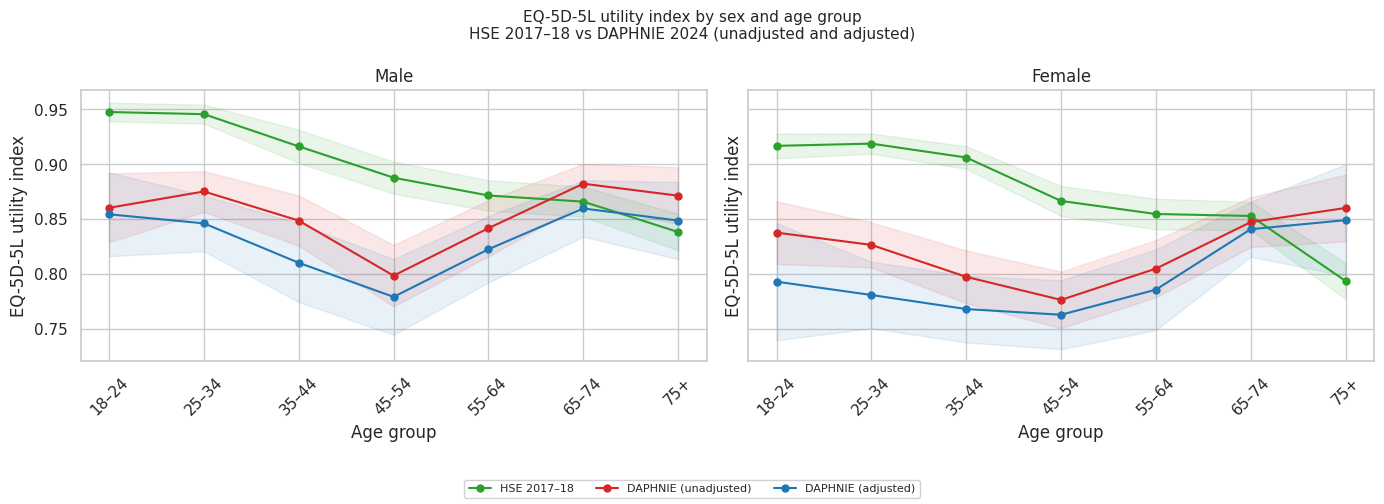

In [19]:
# EQ_index subgroup norm plot: adjusted DAPHNIE vs HSE reference
age_order = [AGE_LABELS[k] for k in sorted(AGE_LABELS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, sex_lbl in zip(axes, ['Male', 'Female']):
    for cond_label, ds, wts_arr in CONDITIONS:
        sub = sg_eq[(sg_eq['Sex'] == sex_lbl) & (sg_eq['Condition'] == cond_label)]
        sub = sub.set_index('Age group').reindex(age_order)
        ax.plot(
            age_order, sub['mean'],
            marker='o', linewidth=1.5, markersize=5,
            label=cond_label, color=COND_COLORS[cond_label],
        )
        ax.fill_between(
            age_order,
            sub['mean'] - 1.96 * sub['SE'],
            sub['mean'] + 1.96 * sub['SE'],
            color=COND_COLORS[cond_label], alpha=0.10,
        )

    ax.set_title(sex_lbl)
    ax.set_xlabel('Age group')
    ax.set_ylabel('EQ-5D-5L utility index')
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=8, framealpha=0.9)
fig.suptitle('EQ-5D-5L utility index by sex and age group\n'
             'HSE 2017–18 vs DAPHNIE 2024 (unadjusted and adjusted)',
             fontsize=11)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(PLOTS_PATH / 'eq_index_subgroup_norms.png', dpi=150, bbox_inches='tight')
plt.show()